In [1]:
%matplotlib inline

In [2]:
# Imports
import os

SALVUS_FLOW_SITE_NAME = os.environ.get("salome_remote") # Site name given in the installation of Salvus flow
PROJECT_DIR = "simulation_wavefield_output_topo"  

# Add code to keep .gitignore updated to ignore salvus files
gitignore_path = ".gitignore"
with open(gitignore_path, "r+") as f:
    contents = f.read()
    if PROJECT_DIR not in contents:
        f.write(f"\n{PROJECT_DIR}/\n")

import pathlib
import numpy as np
import salvus.namespace as sn
import xarray as xr
import salvus.namespace as sn
from salvus.project.tools.processing import block_processing
from salvus.toolbox.helpers.wavefield_output import (
    WavefieldOutput,
    wavefield_output_to_xarray,
)
import matplotlib.pyplot as plt
from matplotlib import animation
import obspy

# For wavefield output code
from salvus.mesh.unstructured_mesh_utils import read_model_from_h5
from salvus.toolbox.helpers import wavefield_output

#for plotting of wiggles, traces 
from scipy import signal

--> Server: 'https://l.mondaic.com/licensing_server', User: 'salome.bachmann', Group: 'ETHZ_ERDW_EEG'.
--> Negotiating 1 license instance(s) for 'SalvusMesh' [license version 1.0.0] for 1 seconds ...
--> Success! [Total duration: 0.68 seconds]


In [3]:
# Setup of the model domain as a box (same as research module)
domain_2d = sn.domain.dim2.BoxDomain(x0=0, x1=400, y0=0, y1=60)
p = sn.Project.from_domain(path=PROJECT_DIR, domain=domain_2d, load_if_exists=True)

Accordion(children=(HTML(value='\n                <head>\n                <style>\n                td {\n     …

[2026-04-02 08:27:51,941] INFO: Loading project from simulation_wavefield_output_topo.


In [59]:
# # Delete entire project directory to clear all cached metadata
# import shutil
# if pathlib.Path(PROJECT_DIR).exists():
#     shutil.rmtree(PROJECT_DIR)
#     print(f"Deleted {PROJECT_DIR}")

In [7]:
# Loading topography data from swisstopo, data is in a csv file 
# columns are Distance	Altitude	Easting	Northing	Longitude	Latitude
topography_data = np.genfromtxt("topo_test.csv", delimiter="\t", skip_header=1)
# Ensure 2D data and recover if parsing with tab failed
if topography_data.ndim == 1:
    topography_data = np.genfromtxt("topo_test.csv", delimiter=",", skip_header=1)

if topography_data.ndim == 1:
    topography_data = np.genfromtxt("topo_test.csv", delimiter=None, skip_header=1)

topography_data = np.atleast_2d(topography_data)
distance = topography_data[:, 0]  # Distance in km
altitude = topography_data[:, 1]  # Altitude in m

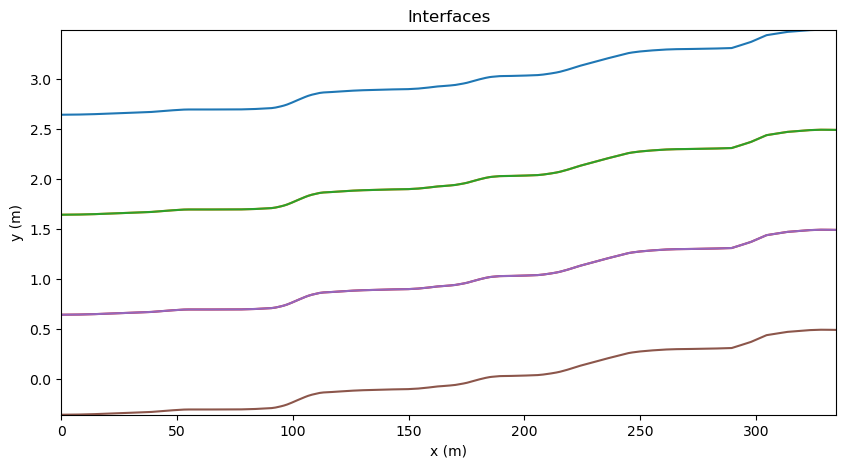

3
0 [2200.] [880.] [2000.]
1 [300.] [150.] [180.]
2 [332.] [0.] [1.225]


In [8]:
# Layered model setup from topography profile

# Convert to float arrays
distance = np.asarray(distance, dtype=float)
altitude = np.asarray(altitude, dtype=float)

# Keep valid rows only
valid = np.isfinite(distance) & np.isfinite(altitude)
distance = distance[valid]
altitude = altitude[valid]

# Sort by distance and drop duplicate x values
order = np.argsort(distance)
distance = distance[order]
altitude = altitude[order]
distance, unique_idx = np.unique(distance, return_index=True)
altitude = altitude[unique_idx]
distance = distance - distance.min()

# If distance is in km, convert to meters (heuristic for short profiles)
if np.nanmax(distance) < 20.0:
    distance = distance * 1000.0

# Use topography as the top boundary guide
x_min = float(distance.min())
x_max = float(distance.max())

# Keep topography shape but scale relief to avoid highly distorted curved elements
relief = altitude - np.mean(altitude)
max_abs_relief = np.max(np.abs(relief))
if max_abs_relief > 0.0:
    relief = relief / max_abs_relief
top_surface = 3.0 + 0.5 * relief

# Smooth and resample profile to avoid sharp geometric kinks that invert Jacobians
window = max(5, (len(top_surface) // 25) | 1)
kernel = np.ones(window, dtype=float) / window
pad = window // 2
top_surface_padded = np.pad(top_surface, (pad, pad), mode="edge")
top_surface = np.convolve(top_surface_padded, kernel, mode="valid")
distance_resampled = np.linspace(x_min, x_max, 400)
top_surface = np.interp(distance_resampled, distance, top_surface)
distance = distance_resampled

# Other interfaces follow the same shape at 1 m and 2 m below top
interface_1m = top_surface - 1.0
interface_2m = top_surface - 2.0

# Bottom boundary for the 3rd layer (another 1 m below)
bottom_surface = top_surface - 3.0

# All interfaces use the same x-extent: distance
layers_x = [
    distance.copy(),  # top boundary
    distance.copy(),  # boundary 1 m below top
    distance.copy(),  # boundary 2 m below top
    distance.copy(),  # bottom boundary
]

layers_y = [
    top_surface,
    interface_1m,
    interface_2m,
    bottom_surface,
]

# Defining model parameters (vp, vs and rho) for earth, snow and air, earth and air velocities taken from https://pburnley.faculty.unlv.edu/GEOL452_652/seismology/notes/SeismicNotes10RVel.html
vp = np.array([2200, 300, 332])
#vs = np.array([0,0,0])
vs = np.array([880, 150,0])
rho = np.array([2000, 180, 1.2250])

interpolation_styles = ["linear"] * len(layers_x)

splines = sn.toolbox.get_interpolating_splines(
    layers_x, layers_y, kind=interpolation_styles
)

# Plotting the layer boundaries to check if they are correct
f = plt.figure(figsize=(10, 5))
x_plot = np.linspace(x_min, x_max, 1000)
for top, bot in splines:
    plt.plot(x_plot, top(x_plot))
    plt.plot(x_plot, bot(x_plot))

plt.xlabel("x (m)")
plt.ylabel("y (m)")
plt.title("Interfaces")
plt.xlim(x_min, x_max)
plt.ylim(min(bottom_surface.min(), 0.0), max(top_surface.max(), 3.0))
plt.show()

# Genetarte mesh
# Maximum frequency to resolve with elements_per_wavelength.
max_frequency = 50

# Print lenght of splines because of size mismatch between splines and vs
shp = len(splines)
print(shp)

slowest_velocities = np.array([
    880,   # earth
    150,   # snow
    150,   # air layer meshing controlled by snow below --> need this because else slowest_velocities gives an errror because it goes to infinity
])

# Generate the mesh
# Increased elements_per_wavelength from 2 to 4 to properly resolve topography and avoid mesh inversion issues that cause "Indefinite Jacobian" errors
mesh, bnd = sn.toolbox.generate_mesh_from_splines_2d(
    x_min=x_min,
    x_max=x_max,
    splines=splines,
    elements_per_wavelength=4,
    maximum_frequency=max_frequency,
    use_refinements=False,
    slowest_velocities=slowest_velocities,
    absorbing_boundaries=None,
)

mesh = np.sum(mesh)

# Add info about absorbing boundaries when enabled
if bnd is not None:
    bnd = min(float(bnd), 0.5)
    mesh.attach_global_variable("max_dist_ABC", bnd)
    mesh.attach_global_variable("ABC_side_sets", ", ".join(["x0", "x1", "y0"]))
    mesh.attach_global_variable("ABC_vel", float(min(vs[vs > 0])))
    mesh.attach_global_variable("ABC_freq", max_frequency / 2.0)
    mesh.attach_global_variable("ABC_nwave", 1.0)

# Attaching parameters (vp,vs,rho) to mesh 
nodes = mesh.get_element_nodes()[:, :, 0]
vp_a, vs_a, ro_a = np.ones((3, *nodes.shape))
for _i, (vp_val, vs_val, ro_val) in enumerate(zip(vp, vs, rho)):
    # Find which elements are in a given region.
    idx = np.where(mesh.elemental_fields["region"] == _i)

    # Set parameters in that region to a constant value.
    vp_a[idx] = vp_val
    vs_a[idx] = vs_val
    ro_a[idx] = ro_val

# Attach parameters.
for k, v in zip(["VP", "VS", "RHO"], [vp_a, vs_a, ro_a]):
    mesh.attach_field(k, v)

# Attach acoustic / elastic flag.
mesh_2d_layered = sn.toolbox.detect_fluid(mesh)

# Checking which values are assigned to which layer: LAYER 0 IS THE BOTTOM LAYER
np.unique(mesh.elemental_fields["region"])
for i in range(3):
    idx = mesh.elemental_fields["region"] == i
    print(i,
          np.unique(mesh.elemental_fields["VP"][idx]),
          np.unique(mesh.elemental_fields["VS"][idx]),
          np.unique(mesh.elemental_fields["RHO"][idx]))

# Plot Mesh check (widget fallback for VS Code renderer issues)
from IPython.display import display
try:
    display(mesh_2d_layered)
except Exception as e:
    print("Interactive mesh renderer unavailable in this frontend:", e)
    print(mesh_2d_layered)

In [11]:
# Soure located in the middle of the domain in x, halfway in the snow layer
# code to print the coordinates of the source location based on layer extent

# Delete existing event when re-running this cell
if "event_wavefield_output" in p.events.list():
    p.events.delete(event_name="event_wavefield_output")

x_half = (x_min + x_max) / 2.0
# Place source midway in the snow layer (between 1 m and 2 m below top)
y_snow_top = np.interp(x_half, distance, interface_1m)
y_snow_bottom = np.interp(x_half, distance, interface_2m)
y_half = 0.5 * (y_snow_top + y_snow_bottom)
print(f"Source coordinates: x={x_half:.2f} m, y={y_half:.2f} m")


src = sn.simple_config.source.cartesian.MomentTensorPoint2D(
    x=x_half,
    y=y_half,
    #radius_of_sphere_in_m=6371000.0,
    myy=0,
    mxx=0,
    mxy=3e4,
    # x=15,
    # y=1.5,
    # fx=0.0,
    # fy=-1.0,
    #f=-1, 
) # fx and fy values dependend on the type and force of source

p.add_to_project(sn.Event(event_name="event_wavefield_output", sources=[src]))

Source coordinates: x=167.40 m, y=1.44 m


In [63]:
# For layered model 
# Delete existing simulation configuration when re-running this cell
sim_cfg_path = pathlib.Path(PROJECT_DIR) / "INTERNAL" / "ENTITIES" / "SIMULATION_CONFIGURATIONS" / "sim_2d_layered.json"
if sim_cfg_path.exists():
    sim_cfg_path.unlink()

p.add_to_project(
    sn.UnstructuredMeshSimulationConfiguration(
        name="sim_2d_layered",
        unstructured_mesh=mesh_2d_layered,
        event_configuration=sn.EventConfiguration(
        wavelet=sn.simple_config.stf.Ricker(center_frequency=10,
        time_shift_in_seconds=0.3), 
        waveform_simulation_configuration=sn.WaveformSimulationConfiguration(
            start_time_in_seconds=-0.3,
            end_time_in_seconds=2.0,
            spectral_element_order=2
            ),
        ),
    ),
)
#p.viz.nb.simulation_setup("sim_2d_layered", events=["event_wavefield_output"])

In [64]:
# Layered
p.simulations.launch(
    simulation_configuration="sim_2d_layered",
    events=p.events.list(),
    site_name="salome_remote", 
    ranks_per_job=1,
    extra_output_configuration={
        "volume_data": {
            "sampling_interval_in_time_steps": 50,
            "fields": ["velocity", "displacement"], 
        },
    },
)
p.simulations.query(block=True)

[2026-04-01 18:33:10,329] INFO: Submitting job ...


Uploading 1 files...

🚀  Submitted job_2604011833333491_a0cf5f0f1b@salome_remote


VBox()

True

In [9]:
# Plotting wvaefield output at one point in time
out_2d_layered = p.simulations.get_simulation_output_directory("sim_2d_layered", "event_wavefield_output")

vel_wo_layered = wavefield_output.WavefieldOutput.from_file(
    pathlib.Path(
        out_2d_layered,
        "volume_data_output.h5",
    ),
    "velocity",
    "volume",
)

# Converting to an x array
vel_2d_layered = wavefield_output.wavefield_output_to_xarray(
    vel_wo_layered,
    points=[np.linspace(0, 400, 101), np.linspace(0, 60, 101)],
)

Finding enclosing elements (pass 1 of auto):   0%|          | 0/10201 [00:00<?, ?it/s]

Finding enclosing elements (pass 2 of auto):   0%|          | 0/9965 [00:00<?, ?it/s]

Finding enclosing elements (pass 3 of auto):   0%|          | 0/9936 [00:00<?, ?it/s]

Finding enclosing elements (pass 4 of auto):   0%|          | 0/9936 [00:00<?, ?it/s]

Finding enclosing elements (pass 5 of auto):   0%|          | 0/9936 [00:00<?, ?it/s]

Finding enclosing elements (pass 6 of auto):   0%|          | 0/9936 [00:00<?, ?it/s]

Finding enclosing elements (pass 7 of auto):   0%|          | 0/9936 [00:00<?, ?it/s]

[2026-04-02 08:28:58,240] WARNING - salvus.mesh.algorithms.unstructured_mesh.utils: 9936 points were not claimed by enclosing elements. Depending on your use case, this may not be an issue.


Extracting wavefield to regular grid:   0%|          | 0/2 [00:00<?, ?it/s]

Finding enclosing elements (pass 1 of auto):   0%|          | 0/1001 [00:00<?, ?it/s]

Extracting wavefield to regular grid:   0%|          | 0/3 [00:00<?, ?it/s]

t range: -0.3 -> 2.0021870777238377
data shape: (401, 1001)


/tmp/ipykernel_3461030/3091143275.py:44: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


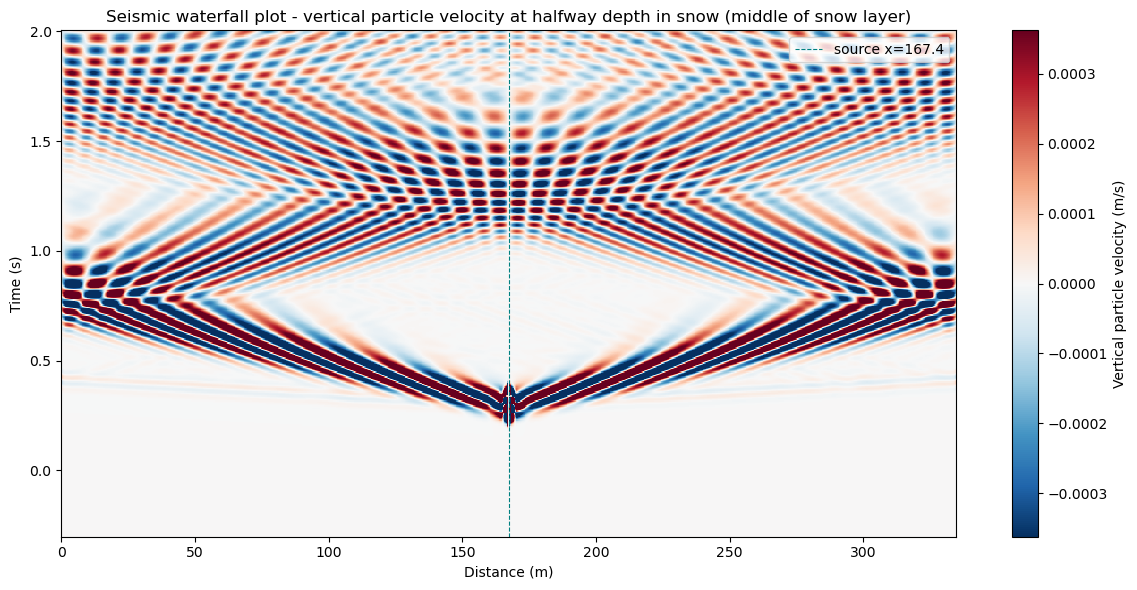

In [12]:
# The y-surface is a surface at 0.5m below the snow-air interface
y_surface = interface_1m - 0.5

# Sample receiver line inside the model extent and interpolate y to this x-grid
x_line = np.linspace(x_min, x_max, 1001)
y_line = np.interp(x_line, distance, y_surface)

# Extract wavefield along receiver line
vel_sg = wavefield_output.wavefield_output_to_xarray(
    vel_wo_layered,
    points=np.column_stack((x_line, y_line)),
)

# Select vertical component and full time range
sg_vy = vel_sg.isel(c=1)

t_vals = sg_vy.t.values
data = sg_vy.values  # shape: (n_t, n_points)

print("t range:", t_vals[0], "->", t_vals[-1])
print("data shape:", data.shape)

# Clip colorscale (robust equivalent)
vmax = np.percentile(np.abs(data), 95)

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.pcolormesh(
    x_line,
    t_vals,
    data,
    shading="auto",
    cmap="RdBu_r",
    vmin=-vmax,
    vmax=vmax,
)
ax.axvline(x=x_half, color="teal", lw=0.8, linestyle="--", label=f"source x={x_half:.1f}")
ax.set_xlabel("Distance (m)")
ax.set_ylabel("Time (s)")
ax.set_xlim(x_min, x_max)
ax.set_title("Seismic waterfall plot - vertical particle velocity at halfway depth in snow (middle of snow layer)")
#ax.set_title("Seismic waterfall plot - vertical particle velocity at snow-earth interface")
ax.legend()
plt.colorbar(im, ax=ax, label="Vertical particle velocity (m/s)")
plt.tight_layout()
plt.show()

Sampling frequency: 173.7 Hz
Nyquist frequency:  86.9 Hz


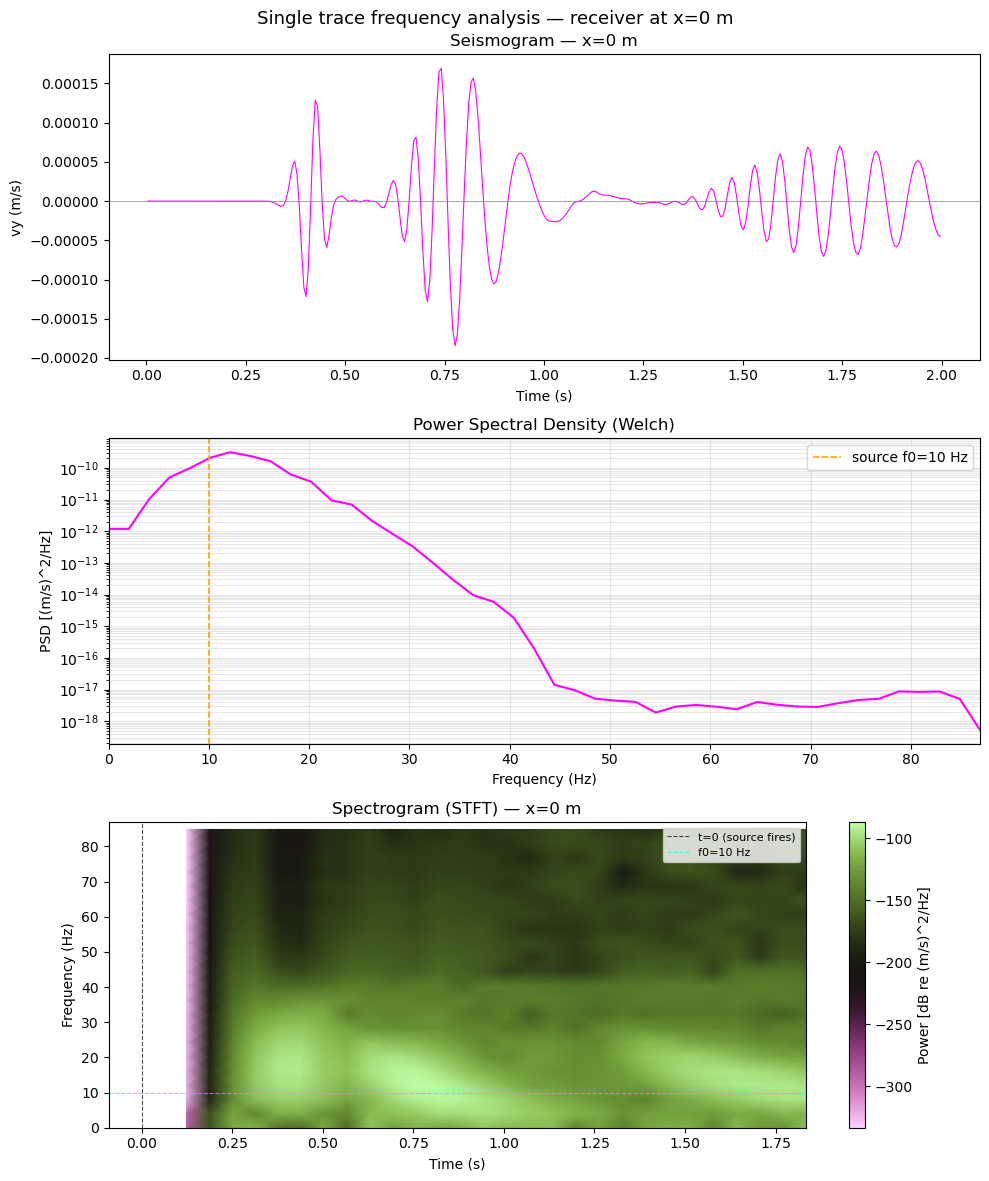

In [13]:

# Extracting trace, picking trace far away from source so that source doesnt dominate
trace = vel_sg.isel(c=1).sel(point=0.0, method="nearest").sel(t=slice(0, 2.0))
t_vals = trace.t.values
y_vals = trace.values

# dt and sampling frequency
dt = float(np.diff(t_vals).mean())
fs = 1.0 / dt
print(f"Sampling frequency: {fs:.1f} Hz")
print(f"Nyquist frequency:  {fs/2:.1f} Hz")

fig, axes = plt.subplots(3, 1, figsize=(10, 12))

# PLotting raw seismogram 
axes[0].plot(t_vals, y_vals, lw=0.8, color="magenta")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel("vy (m/s)")
axes[0].set_title("Seismogram — x=0 m")
axes[0].axhline(0, color="gray", lw=0.5) 

#  Power Spectral Density (Welch method)
# Welch averages many overlapping windows 
# nperseg controls frequency resolution: longer = finer freq bins
nperseg = min(1024, len(y_vals) // 4)

freqs_psd, psd = signal.welch(
    y_vals,
    fs=fs,
    nperseg=nperseg,
    noverlap=nperseg // 2,
    window="hann",           # hann window reduces spectral leakage
    scaling="density",       # units ms^2/HZ
)

axes[1].semilogy(freqs_psd, psd, color="magenta")
axes[1].axvline(10, color="orange", lw=1.2, linestyle="--", label="source f0=10 Hz")
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_ylabel("PSD [(m/s)^2/Hz]")
axes[1].set_title("Power Spectral Density (Welch)")
axes[1].set_xlim(0, fs / 2)
axes[1].legend()
axes[1].grid(True, which="both", alpha=0.3)

# spectrogram 
# nperseg_stft controls the time/frequency resolution tradeoff:
# longer window --< finer frequency resolution, coarser time resolution
#  shorter window --> finer time resolution, coarser frequency resolution
# aim fabput ~3-5 cycles of  lowest frequency of interest per window --> CHANGE THIS DEPENDING ON WHICH FREQUENCY 
nperseg_stft = min(512, len(y_vals) // 8)

freqs_stft, t_stft, Sxx = signal.spectrogram(
    y_vals,
    fs=fs,
    nperseg=nperseg_stft,
    noverlap=nperseg_stft * 3 // 4,   # 75% overlap — smooth time axis
    window="hann",
    scaling="density",
)

#log scale for amplitude — seismic signals span many orders of magnitude
Sxx_log = 10 * np.log10(Sxx + 1e-40)   # dB, small floor to avoid log(0)

im = axes[2].pcolormesh(
    t_stft, freqs_stft, Sxx_log,
    shading="gouraud",
    cmap="vanimo",
)
axes[2].axvline(0,  color="black", lw=0.8, linestyle="--", alpha=0.7, label="t=0 (source fires)")
axes[2].axhline(10, color="cyan",  lw=0.8, linestyle="--", alpha=0.7, label="f0=10 Hz")
axes[2].set_xlabel("Time (s)")
axes[2].set_ylabel("Frequency (Hz)")
axes[2].set_title("Spectrogram (STFT) — x=0 m")
axes[2].set_ylim(0, min(100, fs / 2))   # cap at 100 Hz or Nyquist
axes[2].legend(loc="upper right", fontsize=8)
fig.colorbar(im, ax=axes[2], label="Power [dB re (m/s)^2/Hz]")

plt.suptitle("Single trace frequency analysis — receiver at x=0 m", fontsize=13)
plt.tight_layout()
plt.show()